In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [5]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

In [6]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [7]:
train_box(model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.3738
Epoca [10/100] | Loss: 0.1929
Epoca [20/100] | Loss: 0.0552
Epoca [30/100] | Loss: 0.0215
Epoca [40/100] | Loss: 0.0110
Epoca [50/100] | Loss: 0.0067
Epoca [60/100] | Loss: 0.0048
Epoca [70/100] | Loss: 0.0040
Epoca [80/100] | Loss: 0.0036
Epoca [90/100] | Loss: 0.0032
Epoca [100/100] | Loss: 0.0030

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0057
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


In [8]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

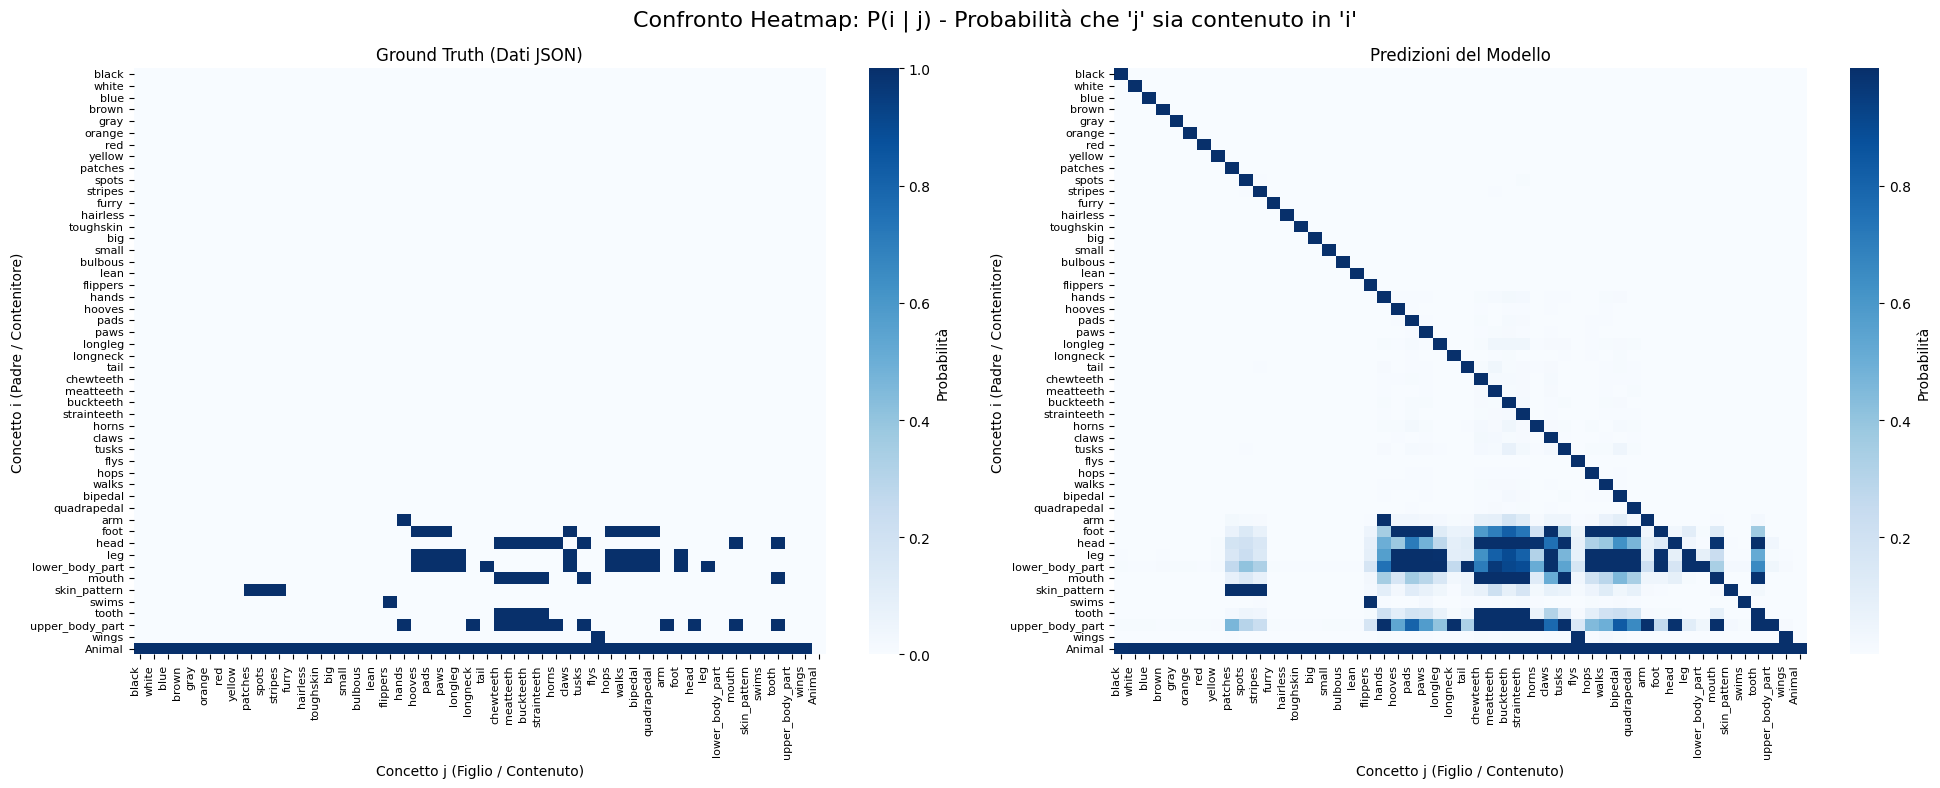

In [9]:
visualize_heatmap_compare(model, dataset, concept2id, id2concept)

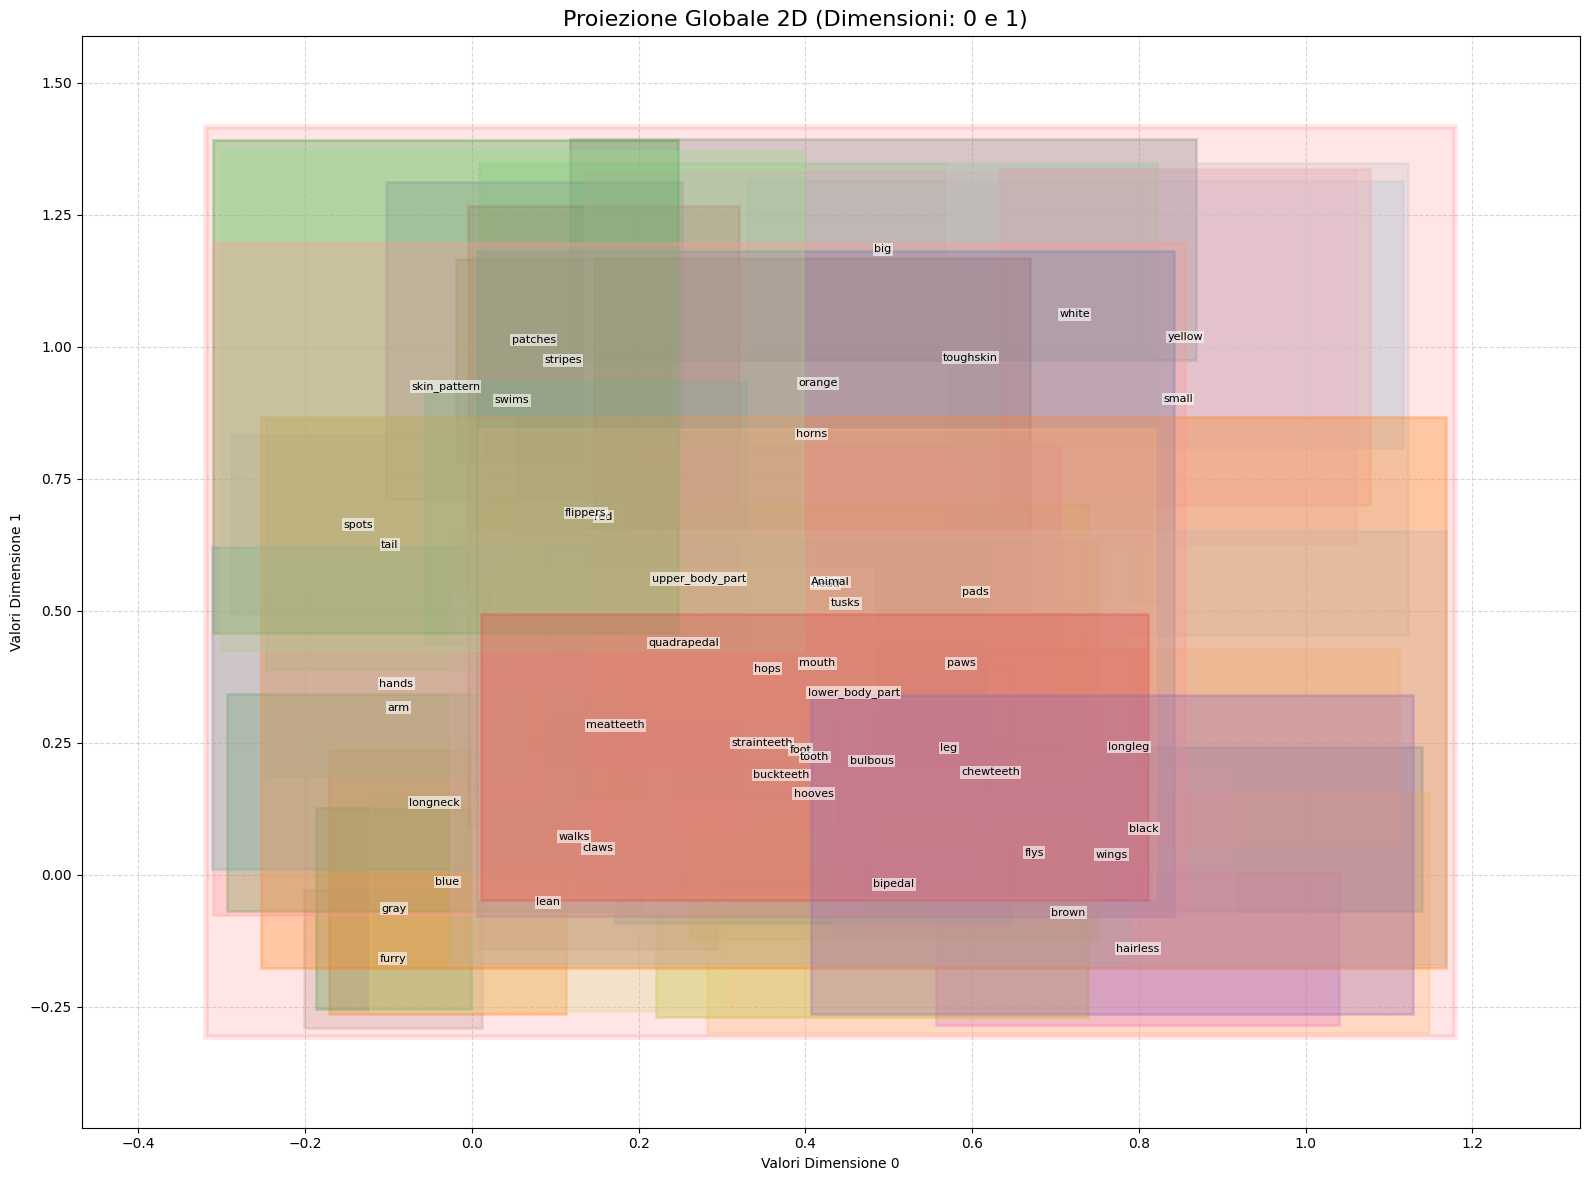

In [10]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(model, id2concept, dim_x=0, dim_y=1)

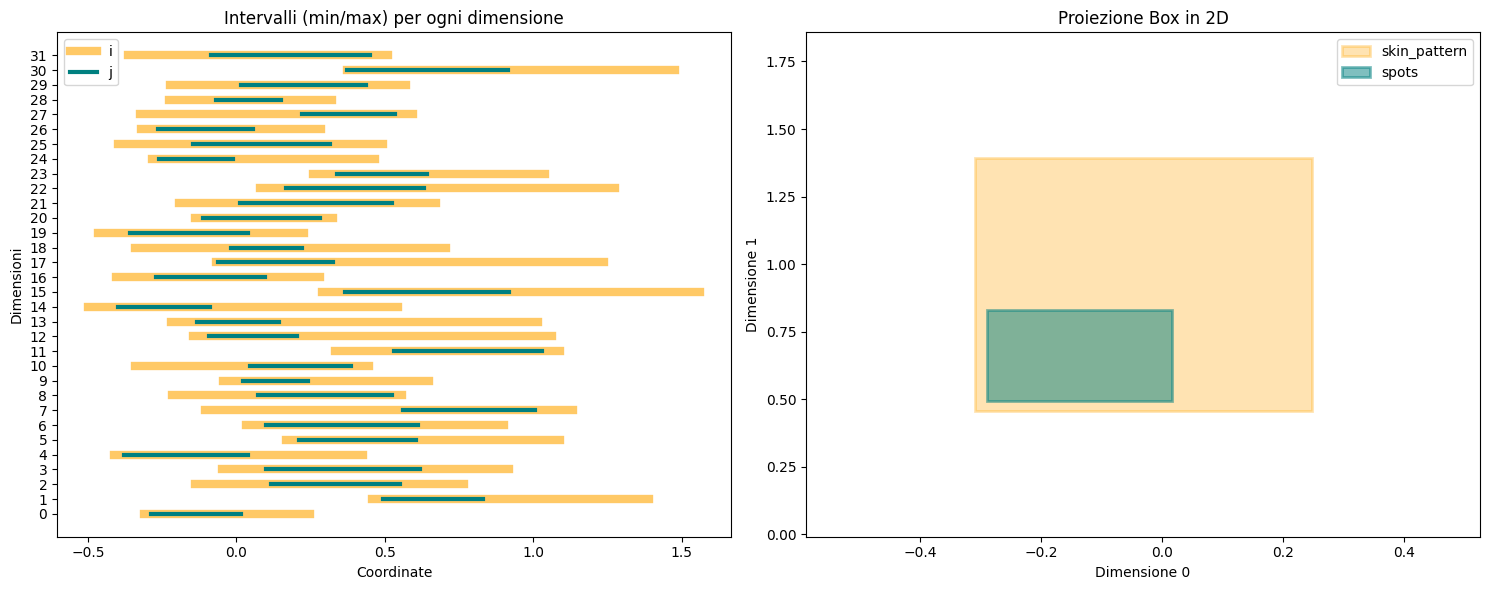

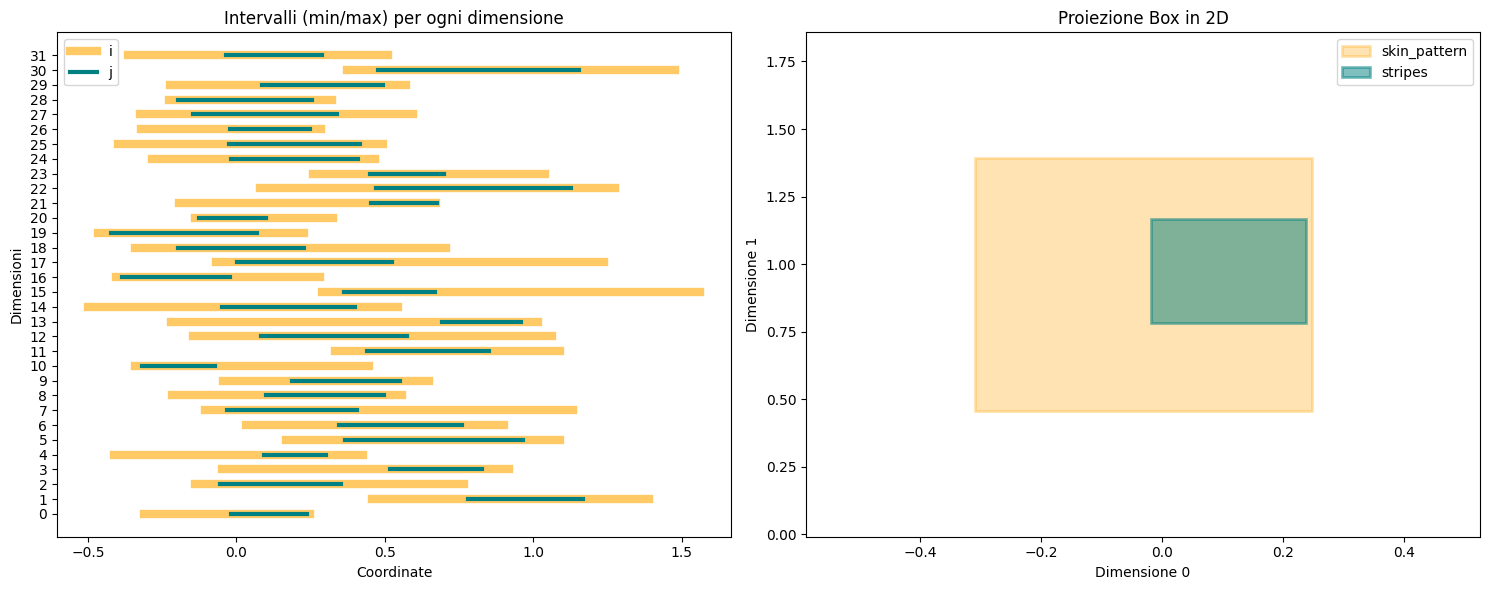

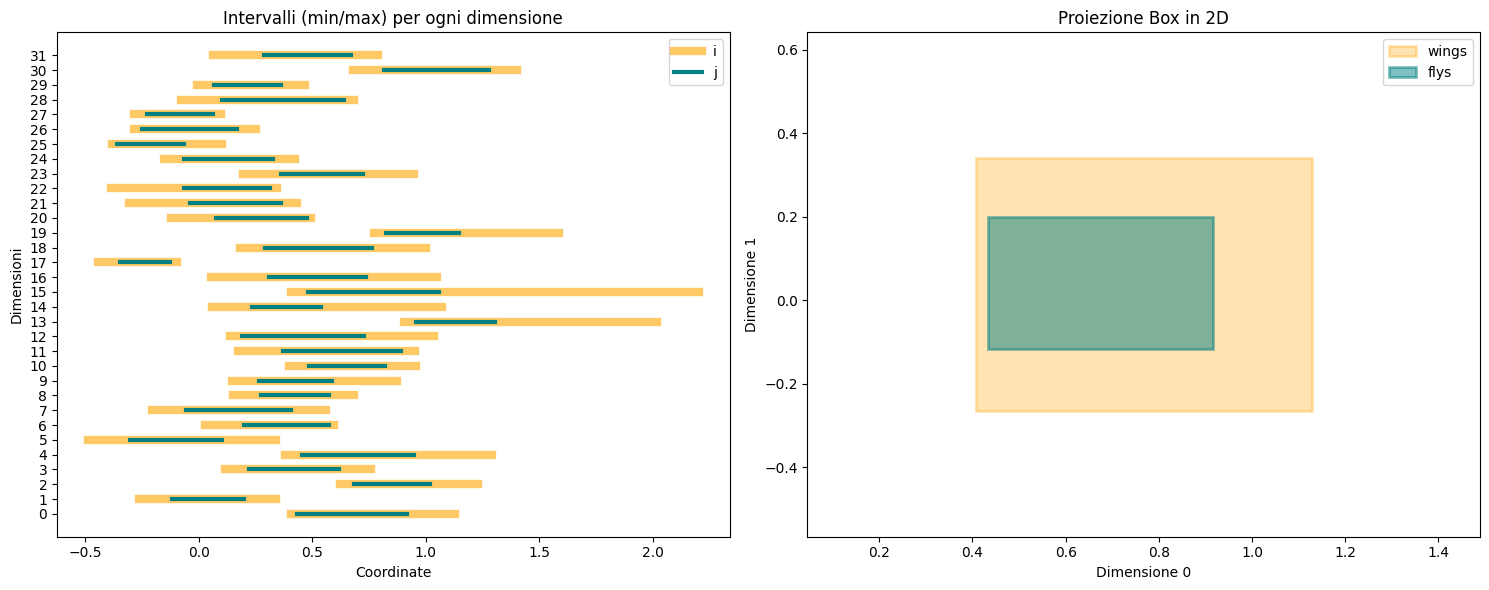

In [11]:
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "spots")
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "stripes")
visualize_concept_hierarchy(model, id2concept, concept2id, "wings", "flys")

In [12]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(model, id2concept)

In [13]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.1794, 1.4159, 1.3004, 1.0007, 1.3752, 1.1070, 0.9688, 1.1650, 1.0811,
         0.9385, 1.0096, 1.0876, 1.1151, 2.2152, 1.0749, 2.2603, 1.1469, 1.2763,
         1.2359, 1.6116, 1.1460, 1.0979, 1.3202, 1.0737, 0.9430, 1.2600, 1.1399,
         1.5729, 1.0317, 1.0099, 1.4924, 1.3614]])
Coordinate z (min) per 'wings': tensor([[ 0.4066, -0.2641,  0.6211,  0.1156,  0.3818, -0.4900,  0.0286, -0.2070,
          0.1511,  0.1474,  0.3952,  0.1710,  0.1389,  0.9025,  0.0599,  0.4074,
          0.0532, -0.4454,  0.1794,  0.7714, -0.1207, -0.3072, -0.3862,  0.1948,
         -0.1551, -0.3813, -0.2857, -0.2873, -0.0800, -0.0060,  0.6780,  0.0639]])


In [14]:
import torch
torch.save(model.state_dict(), "modello_gerarchia.pth")

In [15]:
model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [16]:
box_dict = get_box_dict(model, id2concept)

In [17]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.1794, 1.4159, 1.3004, 1.0007, 1.3752, 1.1070, 0.9688, 1.1650, 1.0811,
         0.9385, 1.0096, 1.0876, 1.1151, 2.2152, 1.0749, 2.2603, 1.1469, 1.2763,
         1.2359, 1.6116, 1.1460, 1.0979, 1.3202, 1.0737, 0.9430, 1.2600, 1.1399,
         1.5729, 1.0317, 1.0099, 1.4924, 1.3614]])
Coordinate z (min) per 'wings': tensor([[ 0.4066, -0.2641,  0.6211,  0.1156,  0.3818, -0.4900,  0.0286, -0.2070,
          0.1511,  0.1474,  0.3952,  0.1710,  0.1389,  0.9025,  0.0599,  0.4074,
          0.0532, -0.4454,  0.1794,  0.7714, -0.1207, -0.3072, -0.3862,  0.1948,
         -0.1551, -0.3813, -0.2857, -0.2873, -0.0800, -0.0060,  0.6780,  0.0639]])


In [18]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [19]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier


model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.092, Acc=98.7% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

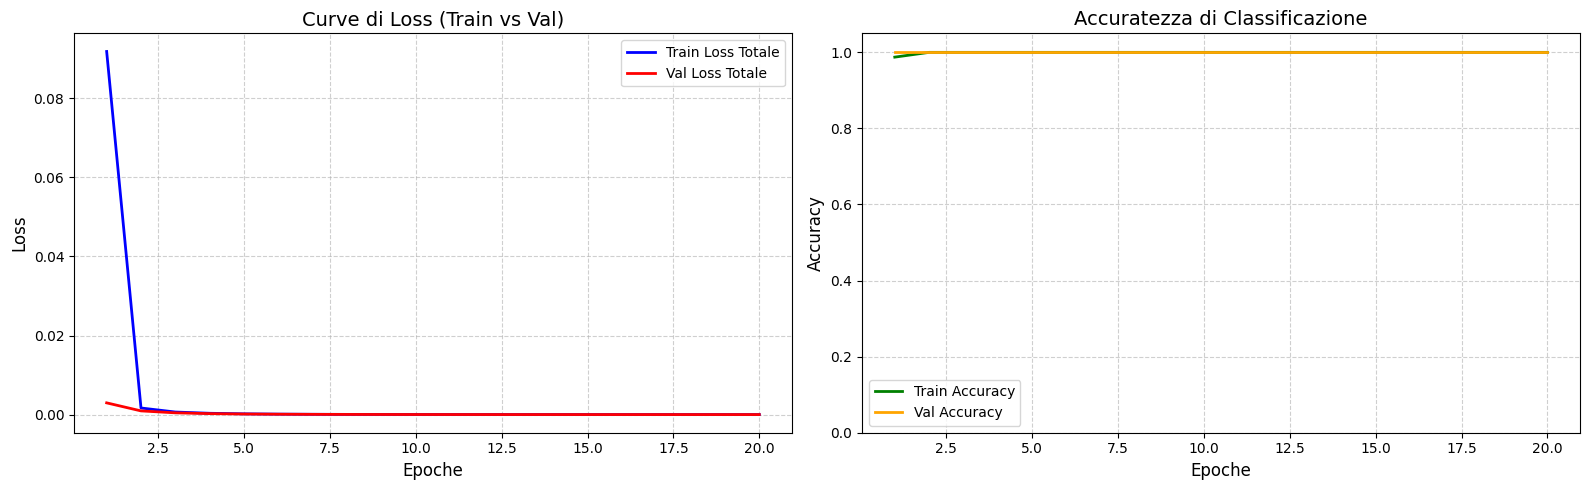

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()